# Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
    ]
)

# Training & Fine Tuning

In [3]:
preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
        ("standard_scaler", StandardScaler())
    ]
)

In [4]:
log_reg_train_pipeline = training_pipeline(model=LogisticRegression(random_state=42))

pipeline = Pipeline(
        steps = preprocessor.steps + log_reg_train_pipeline.steps
    )

hyperparams = [
    {
        "training__solver": ["liblinear"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
    {
        "training__solver": ["saga"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
]

search_log_reg = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    random_state=42
)

search_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END training__C=0.01, training__class_weight=balanced, training__l1_ratio=0, training__max_iter=1000, training__solver=liblinear; total time=   0.9s
[CV] END training__C=1, training__class_weight=balanced, training__l1_ratio=1, training__max_iter=500, training__solver=saga; total time=   1.5s
[CV] END training__C=0.01, training__class_weight=balanced, training__l1_ratio=0, training__max_iter=1000, training__solver=liblinear; total time=   1.6s
[CV] END training__C=0.001, training__class_weight=balanced, training__l1_ratio=1, training__max_iter=1000, training__solver=saga; total time=   1.0s
[CV] END training__C=0.01, training__class_weight=balanced, training__l1_ratio=0, training__max_iter=1000, training__solver=liblinear; total time=   2.2s
[CV] END training__C=1, training__class_weight=balanced, training__l1_ratio=1, training__max_iter=500, training__solver=saga; total time=   2.7s
[CV] END training__C=0.01, training__

/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END training__C=100, training__class_weight=None, training__l1_ratio=0, training__max_iter=500, training__solver=saga; total time=   8.1s
[CV] END training__C=100, training__class_weight=None, training__l1_ratio=1, training__max_iter=2000, training__solver=liblinear; total time=  18.8s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}, {'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescore

In [5]:
best_estimator = get_best_estimator(search_log_reg)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.671970
std      0.011040
min      0.654028
25%      0.671970
50%      0.671970
75%      0.679418
max      0.682464
dtype: float64


## Feature Selection

In [6]:
rcevf_pipeline = feature_selection_pipeline(
    model=LogisticRegression(random_state=42),
    tscv=TSCV
)

lr_pipeline = Pipeline(
    steps= preprocessor.steps + [
            ("fs", rcevf_pipeline)
        ]
    )

X_train_rcevf = lr_pipeline.fit_transform(X_train, y_train)

In [7]:
search_lr = fine_tune(
    pipeline=log_reg_train_pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
    )

search_lr.fit(X_train_rcevf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}, {'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescore

In [8]:
best_estimator = cast(Pipeline, search_lr.best_estimator_)

full_pipeline_lr = Pipeline(
    steps= preprocessor.steps + [
            ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True))
        ] + best_estimator.steps
    )

full_pipeline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature_engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fix_typos', ...), ('drop_cols', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,column,'Comment'


In [10]:
cross_val_scores = cross_validation(
        pipeline=full_pipeline_lr,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.673595
std      0.012077
min      0.655044
25%      0.667569
50%      0.681110
75%      0.681449
max      0.682803
dtype: float64


# Evaluation

In [11]:
y_pred = full_pipeline_lr.predict(X_test)

We are interested in accuracy most.

In [12]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6799

Roc Auc:
0.7429

F1:
0.6759

Recall:
0.6860

Confusion Matrix:
      0     1
0  1545   747
1   682  1490


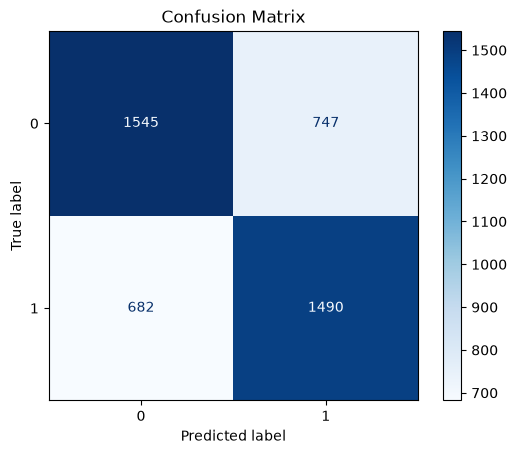

In [13]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

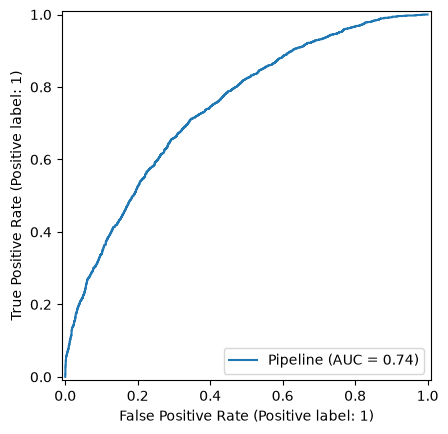

In [14]:
plot_roc_curve(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test
)

In [15]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
errors = X_test.loc[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]

errors["y_true"].describe().transpose()

count    1429.000000
mean        0.477257
std         0.499657
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: y_true, dtype: float64

In [16]:
proba = full_pipeline_lr.predict_proba(X_test)[:, 1]
errors["proba_pos"] = proba[wrong]

# false positives vs false negatives
fp = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
fn = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

fp.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
ATP,747.0,35.491299,1.0,25.0,37.0,48.0,65.0,15.895634
Date,747,2025-01-24 02:01:26.746988,2024-04-08 00:00:00,2024-08-13 12:00:00,2025-02-17 00:00:00,2025-06-30 00:00:00,2025-11-13 00:00:00,NaN
Best of,747.0,3.32664,3.0,3.0,3.0,3.0,5.0,0.73981
player1_Rank,747.0,52.14324,1.0,18.0,40.0,68.0,617.0,54.066235
player2_Rank,747.0,98.902276,2.0,44.0,67.0,113.0,937.0,106.262358
player1_Pts,747.0,1845.772423,57.0,822.0,1238.0,2317.5,11480.0,1676.655444
player2_Pts,747.0,998.282463,17.0,533.5,821.0,1155.0,9590.0,867.668313
player1_B365,744.0,1.525269,1.01,1.36,1.53,1.67,2.1,0.228397
player2_B365,744.0,2.969395,1.7,2.2,2.5,3.2,29.0,1.651104
player1_BFE,102.0,1.608333,1.14,1.3925,1.615,1.805,2.3,0.25201


In [17]:
# plt.hist(fp["player1_Rank"], bins=100, range=(1, 200), alpha=0.5, label='Loser Rank')
# plt.hist(fp["player2_Rank"], bins=100, range=(1, 200), alpha=0.5, label='Winner Rank')

# plt.xlabel('Ranking')
# plt.ylabel('Frequency')
# plt.title('Winner - Loser Ranking')
# plt.legend()

# plt.show()

In [18]:
# plot_difference(
#     dataframe=fp,
#     first_col="player1_Rank",  
#     second_col="player2_Rank",
# )